# **🧾 Fake Bills Detection Using K-Nearest Neighbors (KNN)**

***By Muhammad Shayan Haider***

# **🧠 Introduction**

Fake currency detection is a crucial application of machine learning in the finance and banking sectors. This project aims to classify fake and genuine bills using the K-Nearest Neighbors (KNN) algorithm based on provided features such as variance, skewness, kurtosis, and entropy.

# **📦 Importing Required Libraries**

We start by importing all the necessary libraries for data analysis, visualization, and model building.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# **📂 Loading the Dataset**

We load the dataset containing bill information.

In [3]:
df = pd.read_csv("fake_bills.csv")

# **👀 Initial Data Preview**

Let’s look at the first few rows to understand the data structure.

In [4]:
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# **ℹ️ Dataset Information**

We check basic info such as column names, data types, and null values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


# 📈 **Statistical Summary**

We explore the dataset’s statistical properties to understand feature distribution.

In [6]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [7]:
df.shape

(1500, 7)

# **Cleaning & Removing Duplicates:**

# 📊 **Checking for Missing Values**

We ensure there are no missing values that could affect model accuracy.

In [8]:
df.isnull().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0


# 📊 **Filling Null Values with Median**

We ensure that the null values filled with their median.

In [9]:
df.fillna(df.mean(), inplace=True)

In [10]:
df.isnull().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,0
margin_up,0
length,0


# 📊 **Checking for Duplicate Values**

We ensure there are no duplicate values that could affect model accuracy.

In [11]:
df.duplicated().sum()

np.int64(0)

Since, our data is now cleaned and contain no duplicates. Let's move onto the ***preprocessing***...

# 🧩 **Visualizing Data Distribution**

We visualize each feature’s distribution to identify any skewness or outliers.

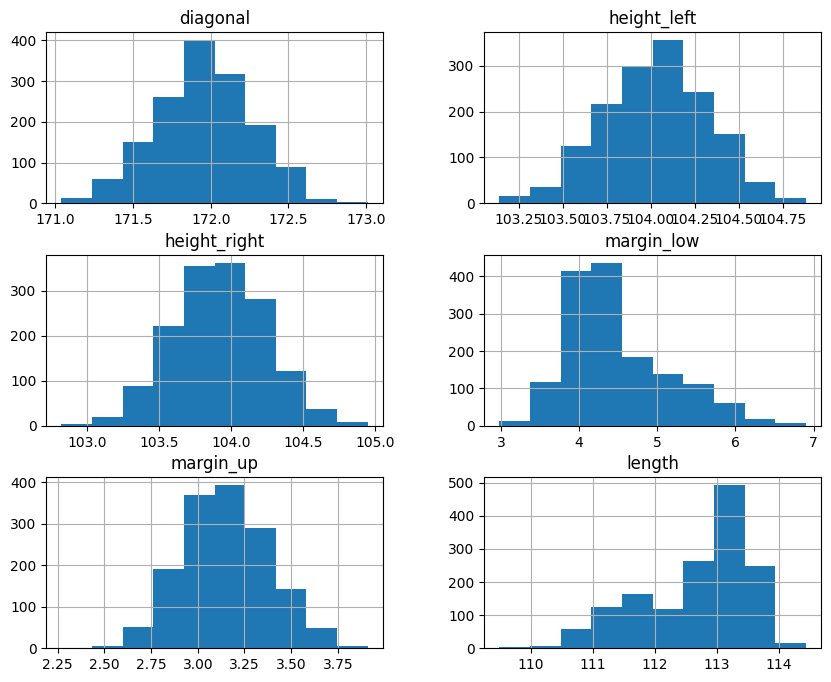

In [12]:
df.hist(figsize=(10,8))
plt.show()

# 🔍 **Correlation Analysis**

We check correlations between features to understand relationships.

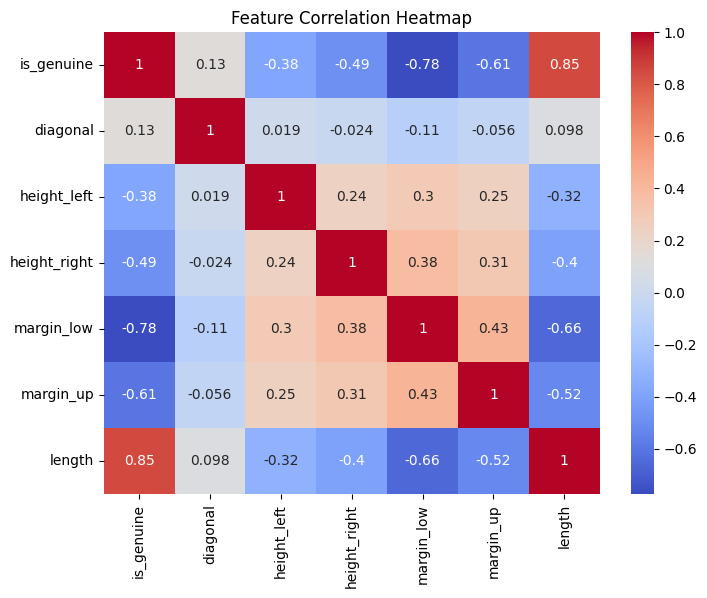

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# ⚙️ **Data Preprocessing**

We separate features and target variables and scale the feature values for better model performance.

In [15]:
features_to_scaled = df[['diagonal', 'height_left', 'height_right', 'margin_low',
       'margin_up', 'length']]

In [16]:
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(features_to_scaled), columns=features_to_scaled.columns)

In [17]:
df_scaled.head()

,diagonal,height_left,height_right,margin_low,margin_up,length
0,0.390863,0.988506,1.000000,0.392857,0.378049,0.674747
1,0.213198,0.126437,0.394366,0.201531,0.439024,0.727273
2,0.837563,0.770115,0.319249,0.362245,0.408537,0.741414
3,0.162437,0.442529,0.525822,0.163265,0.451220,0.812121
4,0.350254,0.655172,0.300469,0.270408,0.737805,0.616162


Since, our data now scaled. Let's move onto the ***model training***...

# ✂️ **Splitting the Dataset**

We split the data into training and testing sets to evaluate model performance properly.

In [18]:
X = df_scaled[['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
y = df['is_genuine']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🤖 **Model Training (KNN Classifier)**

We train the KNN classifier using the training dataset.

In [20]:
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train, y_train)

KNeighborsClassifier()

# **🔮 Making Predictions**

We use the trained model to predict on the test dataset.

In [21]:
y_pred = KNN.predict(X_test)

Since, our model is now trained using KNN classifier. Let's move onto the ***result***...

# 📏 **Model Evaluation**

We evaluate our KNN model using accuracy, precision, recall, and F1-score.

In [22]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:\n\n", classification_report(y_test, y_pred))

Accuracy Score: 0.9833333333333333

Classification Report:

               precision    recall  f1-score   support

       False       1.00      0.95      0.98       110
        True       0.97      1.00      0.99       190

    accuracy                           0.98       300
   macro avg       0.99      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



# ✅ **Confusion Matrix**

We visualize model performance using a confusion matrix.

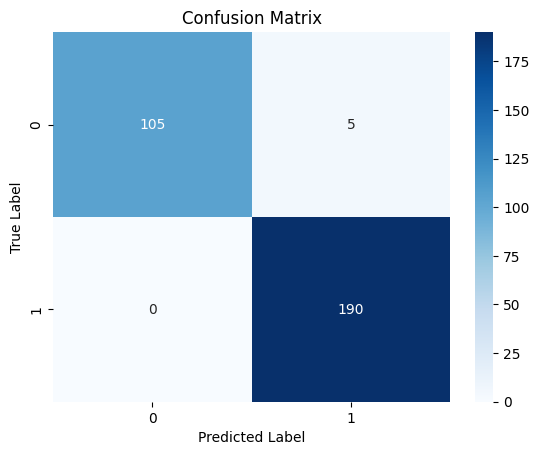

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 🧪 **Testing with Sample Input**

You can test the model manually with a new input to check prediction accuracy.

In [ ]:
diagonal = float(input("Enter diagonal: "))
height_left = float(input("Enter height_left: "))
height_right = float(input("Enter height_right: "))
margin_low = float(input("Enter margin_low: "))
margin_up = float(input("Enter margin_up: "))
length = float(input("Enter length: "))


new_data = [[diagonal, height_left, height_right, margin_low, margin_up, length]]

Enter diagonal: 200.23
Enter height_left: 110.21
Enter height_right: 98.83
Enter margin_low: 3.98
Enter margin_up: 2.90
Enter length: 120.34


In [ ]:
new_data_scaled = scaler.transform(new_data)

In [ ]:
prediction = KNN.predict(new_data_scaled)

In [ ]:
print("Predicted Status:", "Genuine" if prediction[0] else "Fake")

Predicted Status: Genuine


Since, the ***Bill is Genine*** as predicted by our model.

# 🏁 **Conclusion**



1.   The KNN classifier effectively distinguishes between fake and genuine bills.
2.   Proper feature scaling significantly improves model performance.
3. You can tune the value of K to optimize accuracy further.



